This notebook is part of the *orix* documentation https://orix.readthedocs.io. Links to the documentation won’t work from the notebook.

# Clustering orientations

In this tutorial we will cluster Ti crystal orientations using data obtained from a highly deformed specimen, using EBSD, as presented in <cite data-cite="johnstone2020density">Johnstone et al. (2020)</cite>. The data can be downloaded to your local cache via the [orix.data](../reference/generated/orix.data.rst) module.

Import orix classes and various dependencies

In [1]:
# Exchange inline for notebook (or qt5 from pyqt) for interactive plotting
%matplotlib inline

# Import core external
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Colorisation and visualisation
from matplotlib.colors import to_rgb
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.lines import Line2D
from skimage.color import label2rgb

# Import orix classes
from orix import data, plot
from orix.quaternion import Orientation, OrientationRegion, Rotation
from orix.vector import AxAngle, Vector3d

plt.rcParams.update(
    {"font.size": 20, "figure.figsize": (10, 10), "figure.facecolor": "w"}
)

## Import data

Load Ti orientations with the point group symmetry *622* (*D6*).
We have to explicitly allow downloading from an external source.

In [2]:
ori = data.ti_orientations(allow_download=True)
ori

Orientation (193167,) 622
[[ 0.3027  0.0869 -0.5083  0.8015]
 [ 0.3088  0.0868 -0.5016  0.8034]
 [ 0.3057  0.0818 -0.4995  0.8065]
 ...
 [ 0.4925 -0.1633 -0.668   0.5334]
 [ 0.4946 -0.1592 -0.6696  0.5307]
 [ 0.4946 -0.1592 -0.6696  0.5307]]

Extract the symmetry for use later

In [3]:
sym = ori.symmetry

Reshape the orientation mapping data to the correct spatial dimension for the scan and select a subset of the orientations with a suitable size for this demonstration (bottom left corner).

In [4]:
ori = ori.reshape(381, 507)
ori = ori[-100:, :200]

Get an overview of the orientations from orientation maps

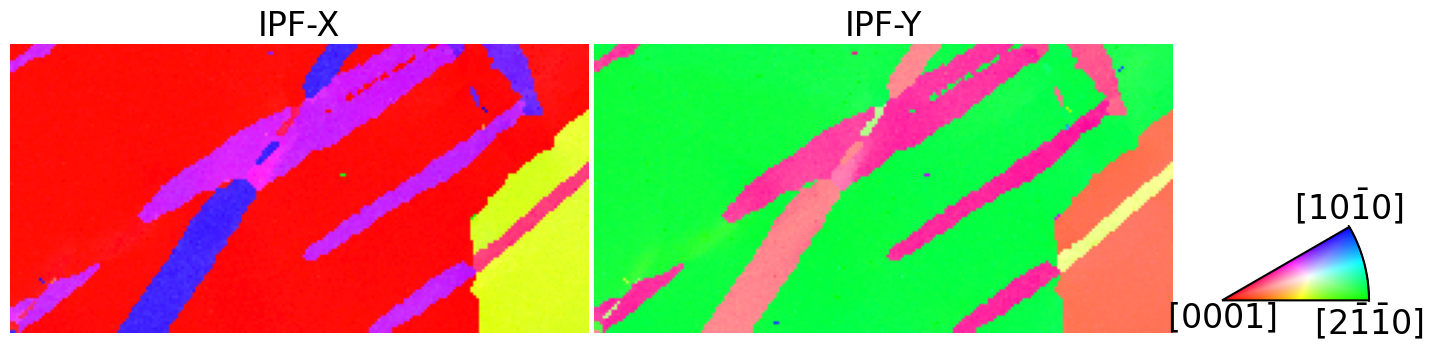

In [5]:
ckey = plot.IPFColorKeyTSL(sym)

directions = [(1, 0, 0), (0, 1, 0)]
titles = ["X", "Y"]

fig, axes = plt.subplots(ncols=2, figsize=(15, 10))
for i, ax in enumerate(axes):
    ckey.direction = Vector3d(directions[i])
    ax.imshow(ckey.orientation2color(ori))
    ax.set_title(f"IPF-{titles[i]}")
    ax.axis("off")

# Add color key
ax_ipfkey = fig.add_axes(
    [0.932, 0.37, 0.1, 0.1],  # (Left, bottom, width, height)
    projection="ipf",
    symmetry=ori.symmetry.laue,
)
ax_ipfkey.plot_ipf_color_key()
ax_ipfkey.set_title("")
fig.subplots_adjust(wspace=0.01)

Map the orientations into the fundamental zone (find symmetrically equivalent orientations with the smallest angle of rotation) of *622*

In [6]:
ori = ori.reduce()

## Compute distance matrix

In [7]:
D = ori.get_distance_matrix()
D = D.reshape(ori.size, ori.size)

## Clustering

For parameter explanations of the DBSCAN algorithm (Density-Based Spatial Clustering for Applications with Noise), see the [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html).

In [8]:
# This call will use about 6 GB of memory, but the data precision of
# the D matrix can be reduced from float64 to float32 save memory:
D = D.astype("float32")

dbscan = DBSCAN(
    eps=0.05,  # Max. distance between two samples in radians
    min_samples=40,
    metric="precomputed",
).fit(D)

unique_labels, all_cluster_sizes = np.unique(
    dbscan.labels_, return_counts=True
)
print("Labels:", unique_labels)

all_labels = dbscan.labels_.reshape(ori.shape)
n_clusters = unique_labels.size - 1
print("Number of clusters:", n_clusters)

Labels: [-1  0  1  2  3  4  5  6]
Number of clusters: 7


Calculate the mean orientation of each cluster

In [9]:
unique_cluster_labels = unique_labels[1:]  # Drop "no-cluster" label -1
cluster_sizes = all_cluster_sizes[1:]

q_mean = [ori[all_labels == l].mean() for l in unique_cluster_labels]
cluster_means = Orientation.stack(q_mean).flatten()

# Map into the fundamental zone
cluster_means.symmetry = sym
cluster_means = cluster_means.reduce()
cluster_means

Orientation (7,) 622
[[-0.7094  0.1616 -0.6682 -0.1553]
 [ 0.8519 -0.3835 -0.3346  0.1231]
 [ 0.8647 -0.4319  0.1888 -0.1735]
 [ 0.8596 -0.4059 -0.2586  0.1716]
 [ 0.785  -0.2649 -0.5591 -0.0311]
 [ 0.7096 -0.6541 -0.2039 -0.1642]
 [ 0.7942  0.3078  0.5239  0.002 ]]

Inspect rotation axes in the axis-angle representation

In [10]:
cluster_means.axis

Vector3d (7,)
[[-0.2293  0.9481  0.2204]
 [-0.7324 -0.639   0.2351]
 [-0.8599  0.3759 -0.3454]
 [-0.7944 -0.5061  0.3358]
 [-0.4276 -0.9026 -0.0502]
 [-0.9284 -0.2895 -0.2331]
 [ 0.5065  0.8622  0.0033]]

Recenter data relative to the matrix cluster and recompute means

In [11]:
ori_recentered = ori * ~cluster_means[0]

# Map into the fundamental zone
ori_recentered.symmetry = sym
ori_recentered = ori_recentered.reduce()

cluster_means_recentered = Orientation.stack(
    [ori_recentered[all_labels == l].mean() for l in unique_cluster_labels]
).flatten()
cluster_means_recentered

Orientation (7,) 1
[[ 1.     -0.      0.0002  0.0001]
 [ 0.8463  0.2653  0.4618  0.0001]
 [ 0.7824 -0.3119 -0.539   0.0007]
 [ 0.7932  0.3013  0.5292 -0.0058]
 [ 0.9674  0.1234  0.2212 -0.0051]
 [ 0.8606  0.4344  0.2657 -0.0034]
 [ 0.9544  0.2864  0.0372  0.075 ]]

Inspect recentered rotation axes in the axis-angle representation

In [12]:
cluster_means_recentered_axangle = AxAngle.from_rotation(
    cluster_means_recentered
)
cluster_means_recentered_axangle.axis

Vector3d (7,)
[[-0.0306  0.8117  0.5832]
 [ 0.4981  0.8671  0.0002]
 [-0.5009 -0.8655  0.0012]
 [ 0.4947  0.869  -0.0095]
 [ 0.487   0.8732 -0.0199]
 [ 0.853   0.5218 -0.0066]
 [ 0.9598  0.1248  0.2514]]

## Visualisation

Specify colours and lines to identify each cluster

In [13]:
colors = []
lines = []
for i, cm in enumerate(cluster_means_recentered_axangle):
    colors.append(to_rgb(f"C{i}"))
    lines.append([(0, 0, 0), tuple(cm.data[0])])
labels_rgb = label2rgb(all_labels, colors=colors, bg_label=-1)

Inspect rotation axes of clusters (in the axis-angle representation) in an inverse pole figure

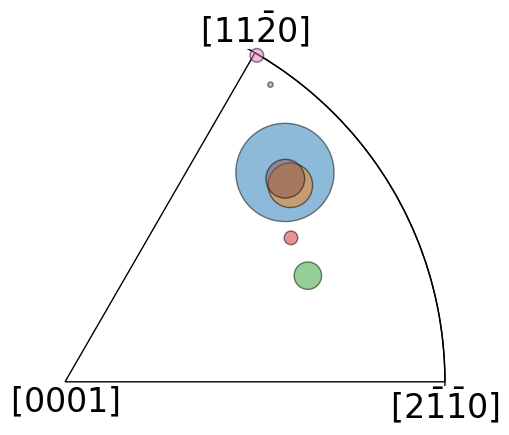

In [14]:
cluster_sizes_scaled = 5000 * cluster_sizes / cluster_sizes.max()
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(projection="ipf", symmetry=sym)
ax.scatter(
    cluster_means.axis, c=colors, s=cluster_sizes_scaled, alpha=0.5, ec="k"
)

Plot a top view of the recentered orientation clusters within the fundamental zone for the *D6* (*622*) point group symmetry of Ti. The mean orientation of the largest parent grain is taken as the reference orientation.

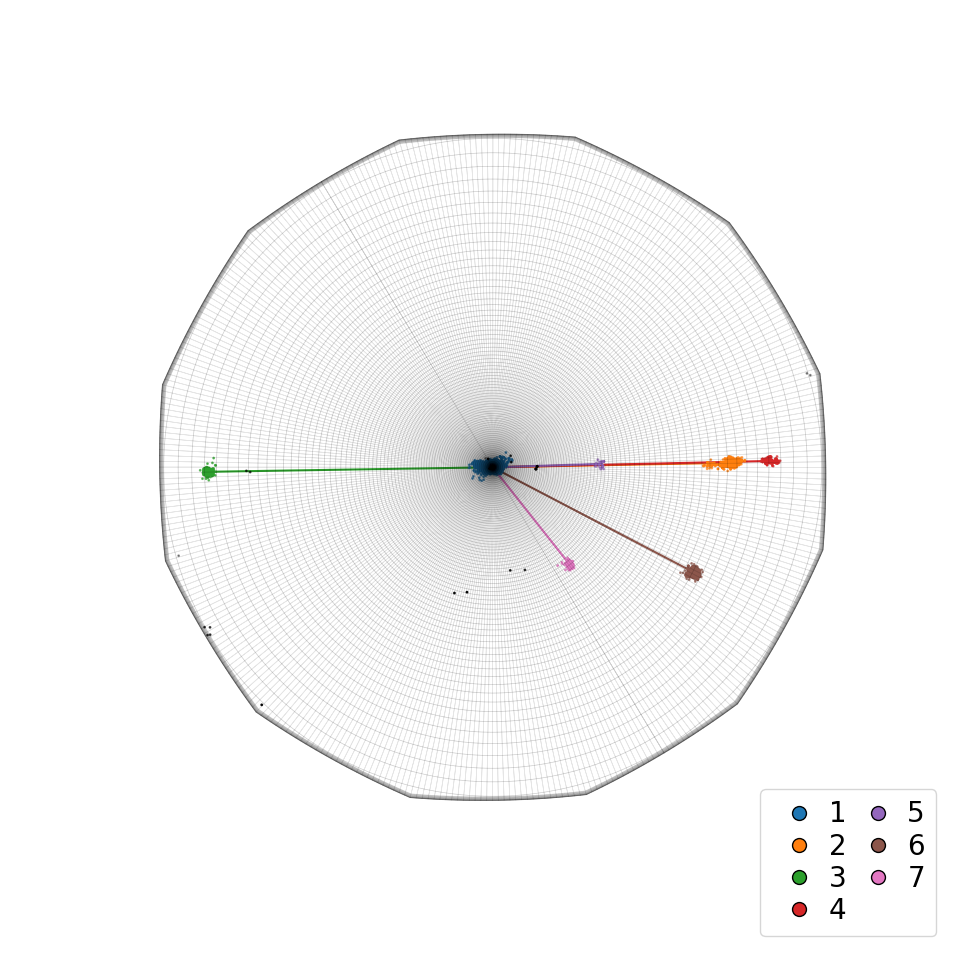

In [15]:
wireframe_kwargs = {
    "color": "black",
    "linewidth": 0.5,
    "alpha": 0.1,
    "rcount": 181,
    "ccount": 361,
}
fig = ori_recentered.scatter(
    projection="axangle",
    wireframe_kwargs=wireframe_kwargs,
    c=labels_rgb.reshape(-1, 3),
    s=1,
    return_figure=True,
)
ax = fig.axes[0]
ax.view_init(elev=90, azim=-30)
ax.add_collection3d(Line3DCollection(lines, colors=colors))

handle_kwds = dict(marker="o", color="none", markersize=10)
handles = []
for i in range(n_clusters):
    line = Line2D(
        [0], [0], label=i + 1, markerfacecolor=colors[i], **handle_kwds
    )
    handles.append(line)
ax.legend(
    handles=handles,
    loc="lower right",
    ncol=2,
    numpoints=1,
    labelspacing=0.15,
    columnspacing=0.15,
    handletextpad=0.05,
);

Plot side view of orientation clusters

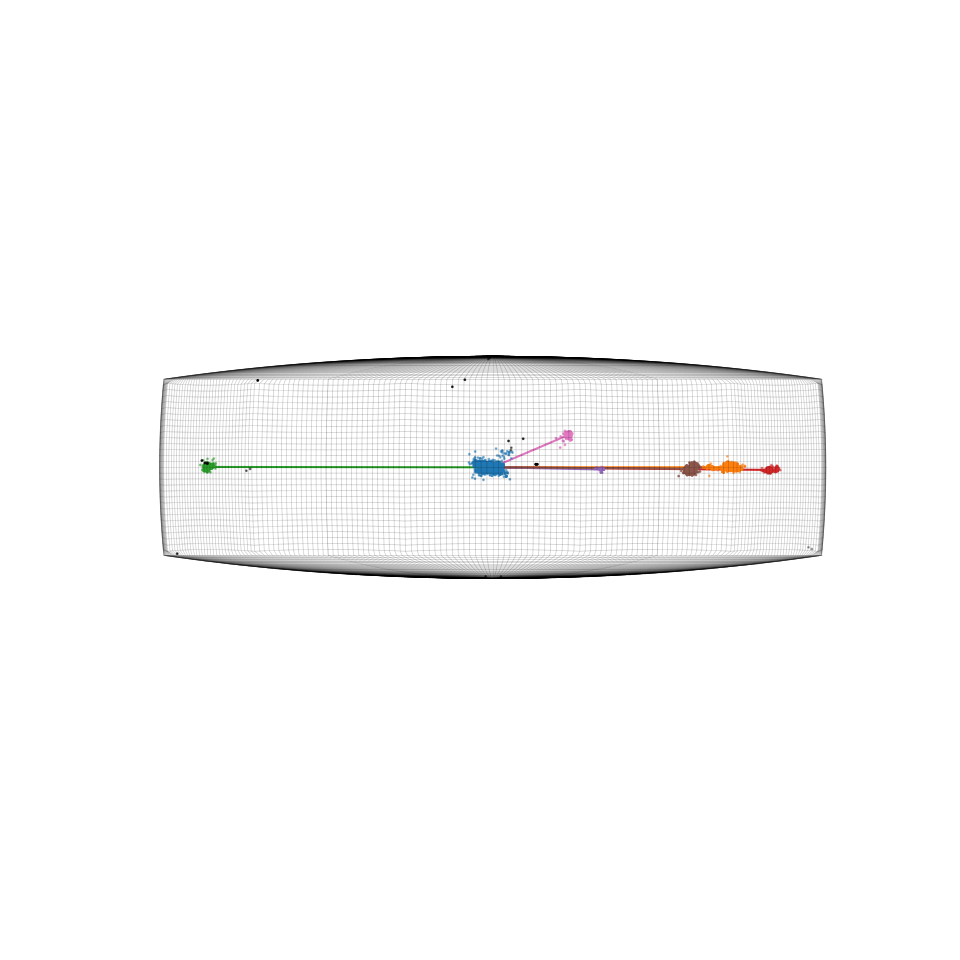

In [16]:
fig2 = ori_recentered.scatter(
    return_figure=True,
    wireframe_kwargs=wireframe_kwargs,
    c=labels_rgb.reshape(-1, 3),
    s=1,
)
ax2 = fig2.axes[0]
ax2.add_collection3d(Line3DCollection(lines, colors=colors))
ax2.view_init(elev=0, azim=-30)

Plot map indicating spatial locations associated with each cluster

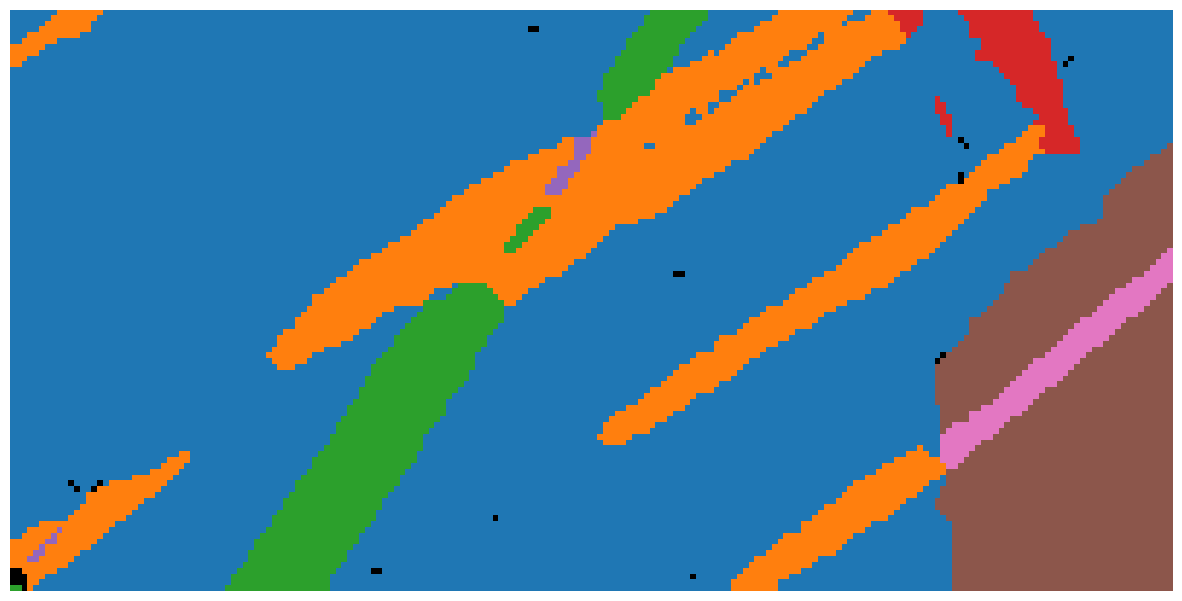

In [17]:
fig3, ax3 = plt.subplots(figsize=(15, 10))
ax3.imshow(labels_rgb)
ax3.axis("off");